# 🌍 Global Economic Indicators Analysis — World Bank Data (2010–2025)

---

### 📌 Objective
Perform a complete Exploratory Data Analysis on World Bank economic data covering 217 countries from 2010 to 2025 — uncovering GDP trends, inflation patterns, unemployment insights, economy size distribution and the impact of COVID-19 on global growth.

### 📂 Dataset
- **File:** world_bank_data_2025.csv
- **Rows:** 3,472
- **Countries:** 217
- **Year Range:** 2010 – 2025
- **Source:** World Bank

### 🛠️ Tools Used
- **NumPy** — Numerical operations
- **Pandas** — Data loading, cleaning, filtering and transformation
- **Matplotlib** — Core visualizations
- **Seaborn** — Statistical visualizations

### 📊 Analyses Performed
1. Top 10 Largest Economies by GDP (2025)
2. Top 10 Countries by GDP per Capita (2025)
3. Average GDP Trend Over Years
4. Global GDP Growth Rate Trend
5. Global Inflation Rate Trend
6. Economy Size Distribution
7. Unemployment vs GDP Growth
8. Top 10 Highest Unemployment Countries
9. Inflation Rate Distribution
10. GDP Growth Distribution by Economy Size
11. GDP vs GDP per Capita by Economy Size
12. Inflation Comparison — 6 Major Countries
13. GDP Growth Heatmap — 6 Countries
14. GDP Stack Plot — 6 Major Economies
15. Final Dashboard

---

## 📦 Importing Libraries

In [28]:
# Importing all required libraries for data manipulation and visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 📥 Loading the Dataset

In [29]:
# Loading the World Bank dataset into a DataFrame
df = pd.read_csv('world_bank_data_2025.csv')

## 🧹 Data Cleaning

Steps performed:
- Drop columns with too many missing values — not useful for analysis
- Fill missing values using country-specific medians — preserves data without losing rows
- Fill remaining nulls with global median as fallback
- Create `economy_size` column using a custom function

In [30]:
# Dropping columns with too many missing values — over 40-75% null
# These columns would introduce too much bias if filled artificially
df.drop(columns=[
    'country_id',
    'Public Debt (% of GDP)',
    'Interest Rate (Real, %)',
    'Government Expense (% of GDP)',
    'Government Revenue (% of GDP)',
    'Tax Revenue (% of GDP)'
], inplace=True)

In [31]:
# Grouping by country once — reused for all median calculations below
# Avoids repeating groupby operation for every column separately
data = df.groupby('country_name')

In [32]:
# Step 1 — Fill missing values using country-specific medians
# GDP Growth filled with 0 — no growth is safer than median for rate columns
# All other columns filled with their own country's median — more meaningful than global median
# map() links each country name to its median value from the groupby result
# All columns filled in ONE fillna() call — clean and efficient
df.fillna({
    'GDP Growth (% Annual)'              : 0,
    'Inflation (CPI %)'                  : df['country_name'].map(data['Inflation (CPI %)'].median()),
    'Unemployment Rate (%)'              : df['country_name'].map(data['Unemployment Rate (%)'].median()),
    'Gross National Income (USD)'        : df['country_name'].map(data['Gross National Income (USD)'].median()),
    'GDP (Current USD)'                  : df['country_name'].map(data['GDP (Current USD)'].median()),
    'GDP per Capita (Current USD)'       : df['country_name'].map(data['GDP per Capita (Current USD)'].median()),
    'Inflation (GDP Deflator, %)'        : df['country_name'].map(data['Inflation (GDP Deflator, %)'].median()),
    'Current Account Balance (% GDP)'   : df['country_name'].map(data['Current Account Balance (% GDP)'].median())
}, inplace=True)

In [33]:
# Step 2 — Fallback: fill remaining nulls with global median
# Some countries had ALL values missing — their country median was also NaN
# Global median fills these edge cases — ensures zero nulls in all columns
df.fillna({
    'Inflation (CPI %)'                  : df['Inflation (CPI %)'].median(),
    'Unemployment Rate (%)'              : df['Unemployment Rate (%)'].median(),
    'Gross National Income (USD)'        : df['Gross National Income (USD)'].median(),
    'GDP (Current USD)'                  : df['GDP (Current USD)'].median(),
    'GDP per Capita (Current USD)'       : df['GDP per Capita (Current USD)'].median(),
    'Inflation (GDP Deflator, %)'        : df['Inflation (GDP Deflator, %)'].median(),
    'Current Account Balance (% GDP)'   : df['Current Account Balance (% GDP)'].median()
}, inplace=True)

In [34]:
# Custom function to classify each country into an economy size category based on GDP
# MEGA   = GDP >= $1 Trillion  (world's largest economies)
# LARGE  = GDP $100B to $1T    (significant economies)
# MEDIUM = GDP $10B to $100B   (mid-sized economies)
# SMALL  = GDP < $10 Billion   (small economies)
def economy(x):
    if (x >= 1e12):
        return 'MEGA'
    elif (x >= 1e11 and x < 1e12):
        return 'LARGE'
    elif (x >= 1e10 and x < 1e11):
        return 'MEDIUM'
    else:
        return 'SMALL'

# Applying function to every row's GDP value — creates economy_size column
df['economy_size'] = df['GDP (Current USD)'].apply(economy)

---
## 📊 Analysis 1 — Top 10 Largest Economies by GDP (2025)

**Question:** Which countries have the biggest total economies in the world?

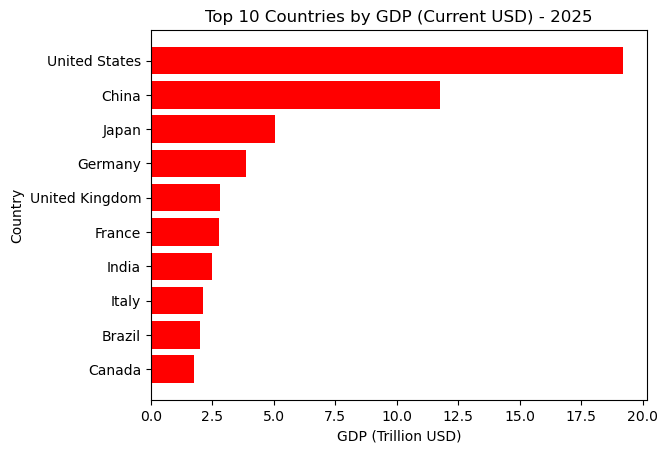

In [35]:
# Filtering only 2025 data — most recent year for current rankings
filtered = df.loc[df['year'] == 2025]

# Sorting by GDP and taking top 10 — sort_values + tail gives highest 10
data = filtered.sort_values('GDP (Current USD)').tail(10)

# Horizontal bar — better for long country names on y-axis
# Dividing by 1e12 converts raw USD to Trillions — cleaner axis labels
plt.barh(data['country_name'], data['GDP (Current USD)'] / 1e12, color='red')
plt.title('Top 10 Countries by GDP (Current USD) - 2025')
plt.xlabel('GDP (Trillion USD)')
plt.ylabel('Country')
plt.show()

## 📊 Analysis 2 — Top 10 Countries by GDP per Capita (2025)

**Question:** Which countries have the highest wealth per person — are they the same as the biggest total economies?

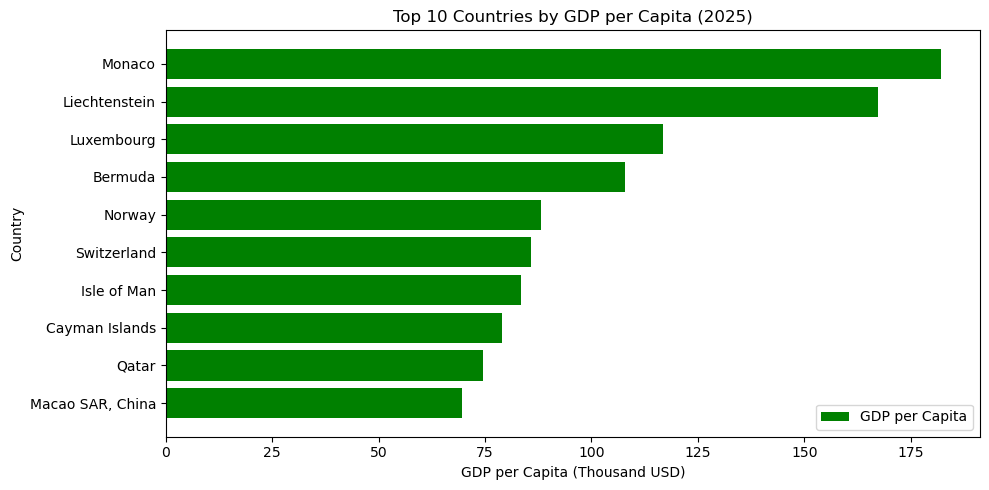

In [36]:
plt.figure(figsize=(10, 5))

# Filtering 2025 data for current per capita rankings
filtered = df.loc[df['year'] == 2025]

# Top 10 countries by GDP per Capita — small wealthy nations dominate this chart
data = filtered.sort_values('GDP per Capita (Current USD)').tail(10)

# Dividing by 1000 converts to thousands — more readable than raw USD values
plt.barh(data['country_name'], data['GDP per Capita (Current USD)'] / 1e3, color='green', label='GDP per Capita')
plt.title('Top 10 Countries by GDP per Capita (2025)')
plt.xlabel('GDP per Capita (Thousand USD)')
plt.ylabel('Country')
plt.legend()
plt.tight_layout()
plt.show()

## 📊 Analysis 3 — Average GDP Trend Over Years

**Question:** How has the average size of world economies grown from 2010 to 2025?

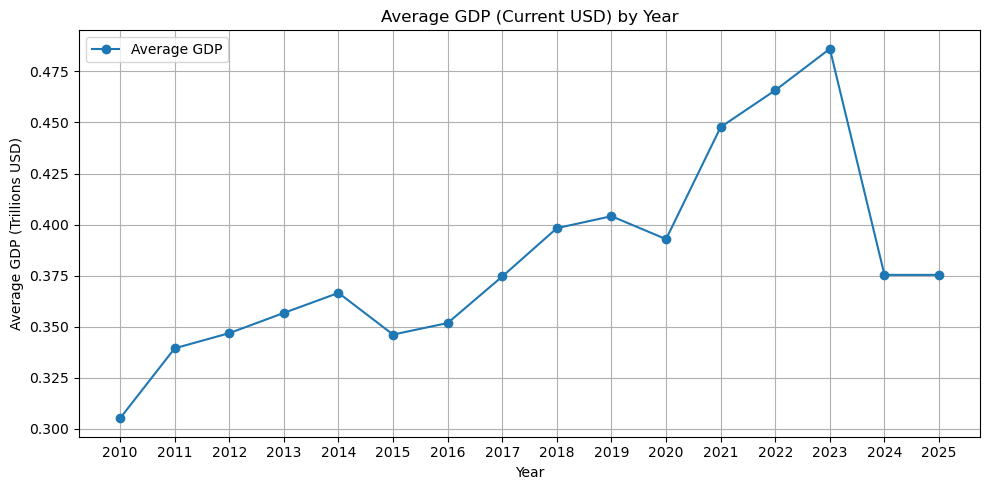

In [37]:
plt.figure(figsize=(10, 5))

# Grouping by year and computing mean GDP across all 217 countries per year
data = df.groupby('year')['GDP (Current USD)'].mean()

# Line plot with markers — each point = average GDP of all countries in that year
plt.plot(data.index, data.values / 1e12, marker='o', label='Average GDP')
plt.title('Average GDP (Current USD) by Year')
plt.xlabel('Year')
plt.ylabel('Average GDP (Trillions USD)')
plt.legend()
plt.grid()

# Showing every year on x-axis — no gaps
plt.xticks(data.index)
plt.tight_layout()
plt.show()

## 📊 Analysis 4 — Global GDP Growth Rate Trend

**Question:** In which year did the global economy shrink — and how fast did it recover after COVID-19?

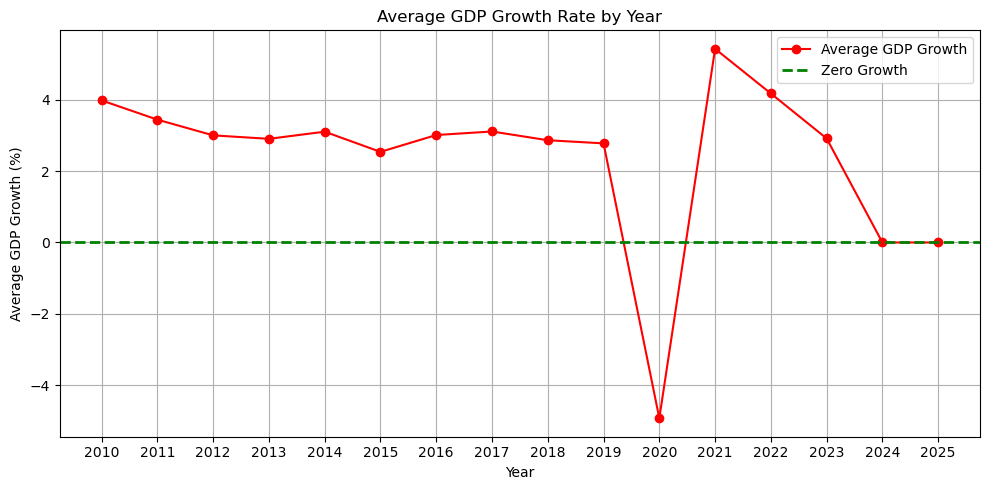

In [38]:
plt.figure(figsize=(10, 5))

# Average GDP growth rate across all countries per year
# Shows rate of growth — not size — revealing the COVID crash clearly
data = df.groupby('year')['GDP Growth (% Annual)'].mean()

plt.plot(data.index, data.values, marker='o', label='Average GDP Growth', color='red')

# Horizontal reference line at 0 — above = growth, below = recession
plt.axhline(y=0, color='green', linestyle='--', linewidth=2, label='Zero Growth')
plt.title('Average GDP Growth Rate by Year')
plt.xlabel('Year')
plt.ylabel('Average GDP Growth (%)')
plt.legend()
plt.grid()
plt.xticks(data.index)
plt.tight_layout()
plt.show()

## 📊 Analysis 5 — Global Inflation Rate Trend

**Question:** When did global inflation spiral dangerously — and is it finally coming under control?

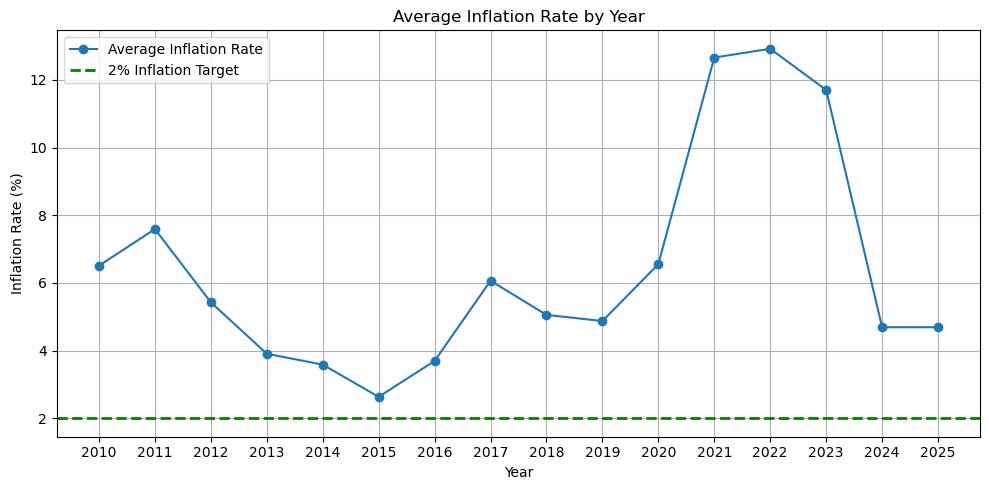

In [39]:
plt.figure(figsize=(10, 5))

# Average GDP Deflator inflation across all countries per year
# GDP Deflator is a broader and more accurate inflation measure than CPI
data = df.groupby('year')['Inflation (GDP Deflator, %)'].mean()

plt.plot(data.index, data.values, marker='o', label='Average Inflation Rate')

# Reference line at 2% — healthy inflation target for most central banks
plt.axhline(y=2, color='green', linestyle='--', linewidth=2, label='2% Inflation Target')
plt.title('Average Inflation Rate by Year')
plt.xlabel('Year')
plt.ylabel('Inflation Rate (%)')
plt.legend()
plt.grid()
plt.xticks(data.index)
plt.tight_layout()
plt.show()

## 📊 Analysis 6 — Economy Size Distribution (2025)

**Question:** How many countries in the world actually have trillion dollar economies?

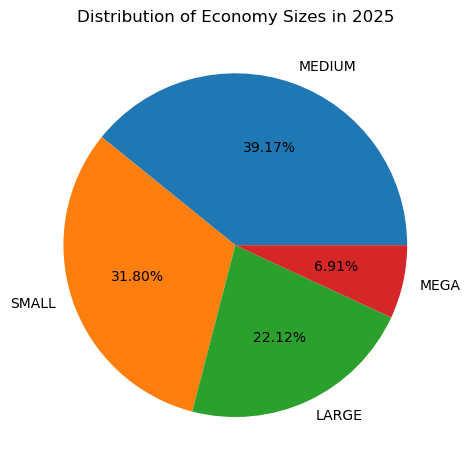

In [40]:
# Filtering 2025 data — one row per country for current size classification
filtered = df.loc[df['year'] == 2025]

# Counting how many countries fall in each economy size category
data = filtered['economy_size'].value_counts()

# Pie chart — shows proportion of each economy size category across all 217 countries
plt.pie(data.values, labels=data.index, autopct='%1.2f%%')
plt.title('Distribution of Economy Sizes in 2025')
plt.tight_layout()
plt.show()

## 📊 Analysis 7 — Unemployment Rate vs GDP Growth

**Question:** Do countries with high unemployment tend to have lower economic growth?

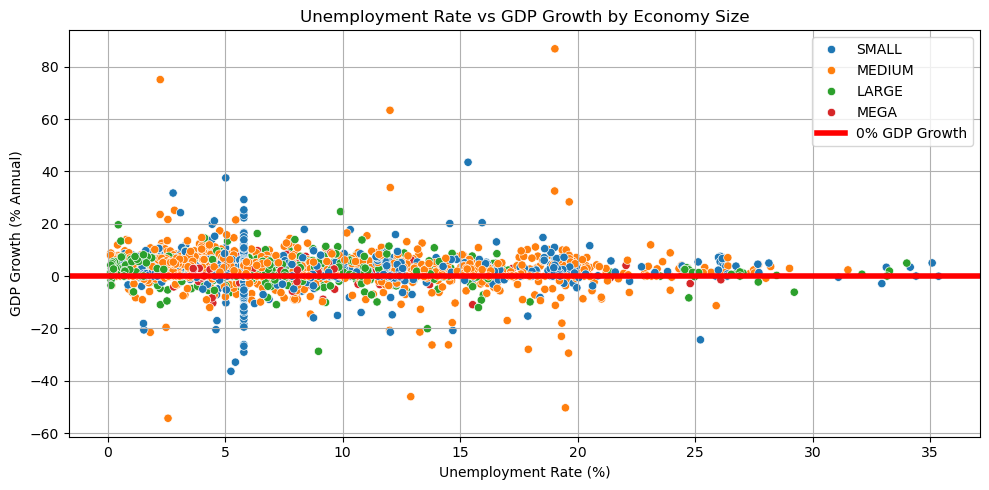

In [41]:
plt.figure(figsize=(10, 5))

# Scatter plot using full dataset — all countries all years
# hue='economy_size' adds a 3rd dimension — reveals if pattern differs by economy size
sns.scatterplot(df, x='Unemployment Rate (%)', y='GDP Growth (% Annual)', hue='economy_size')

# Reference line at 0 — separates growing vs shrinking economies
plt.axhline(y=0, color='red', linestyle='-', linewidth=4, label='0% GDP Growth')
plt.title('Unemployment Rate vs GDP Growth by Economy Size')
plt.xlabel('Unemployment Rate (%)')
plt.ylabel('GDP Growth (% Annual)')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

## 📊 Analysis 8 — Top 10 Highest Unemployment Countries (2025)

**Question:** Which countries suffer from the worst unemployment crisis in 2025?

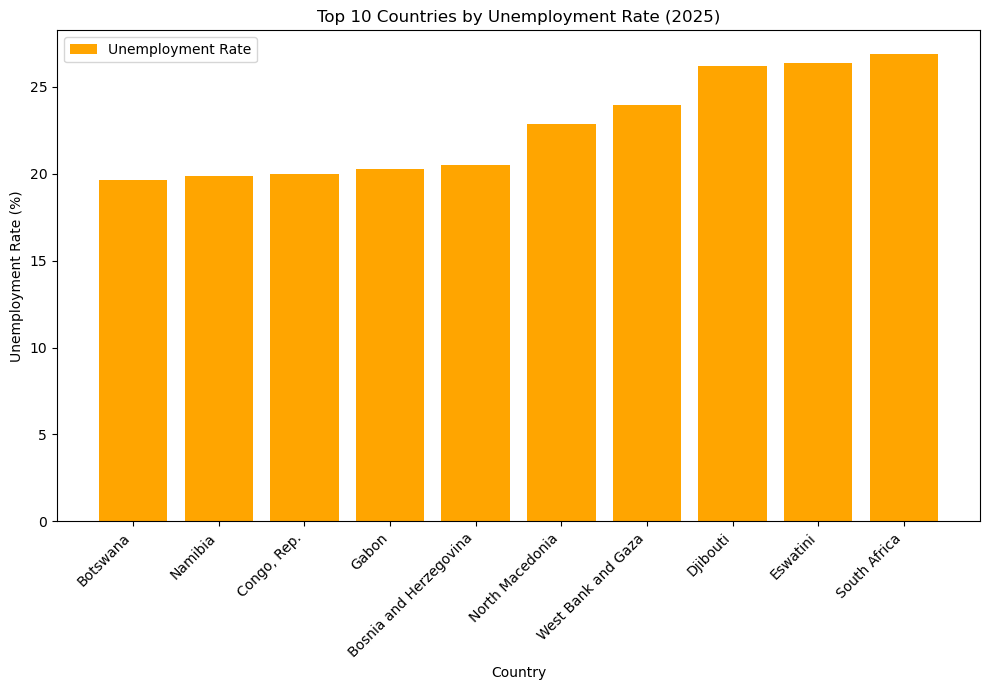

In [42]:
plt.figure(figsize=(10, 7))

# Filtering 2025 and taking top 10 highest unemployment countries
filtered = df.loc[df['year'] == 2025]
data = filtered.sort_values('Unemployment Rate (%)').tail(10)

# Vertical bar chart — different from horizontal bars used elsewhere for visual variety
plt.bar(data['country_name'], data['Unemployment Rate (%)'], color='orange', label='Unemployment Rate')
plt.title('Top 10 Countries by Unemployment Rate (2025)')
plt.xlabel('Country')
plt.ylabel('Unemployment Rate (%)')
plt.legend()

# Rotating labels 45 degrees — prevents overlap for long country names
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 📊 Analysis 9 — Inflation Rate Distribution

**Question:** What inflation rate is most common globally — and how many countries stay within the healthy 2% target?

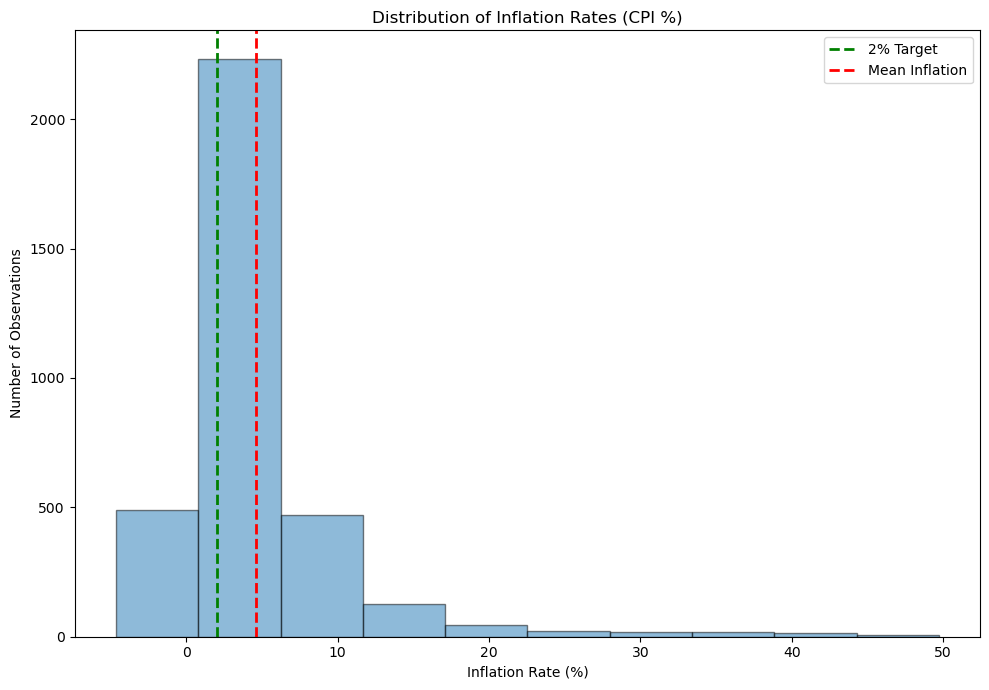

In [43]:
plt.figure(figsize=(10, 7))

# Filtering extreme outliers — hyperinflation above 50% would squish the chart
# Range -5% to 50% captures all meaningful inflation while removing Venezuela-style outliers
data = df.loc[((df['Inflation (CPI %)'] >= -5) & (df['Inflation (CPI %)'] <= 50))]

# Histogram showing distribution of inflation rates across all countries and years
plt.hist(data['Inflation (CPI %)'], edgecolor='black', alpha=0.5)

# Green line = 2% healthy target | Red line = actual global mean inflation
plt.axvline(x=2, color='green', linestyle='--', linewidth=2, label='2% Target')
plt.axvline(x=data['Inflation (CPI %)'].mean(), color='red', linestyle='--', linewidth=2, label='Mean Inflation')
plt.title('Distribution of Inflation Rates (CPI %)')
plt.xlabel('Inflation Rate (%)')
plt.ylabel('Number of Observations')
plt.legend()
plt.tight_layout()
plt.show()

## 📊 Analysis 10 — GDP Growth Distribution by Economy Size

**Question:** Do smaller economies have more volatile GDP growth compared to larger stable economies?

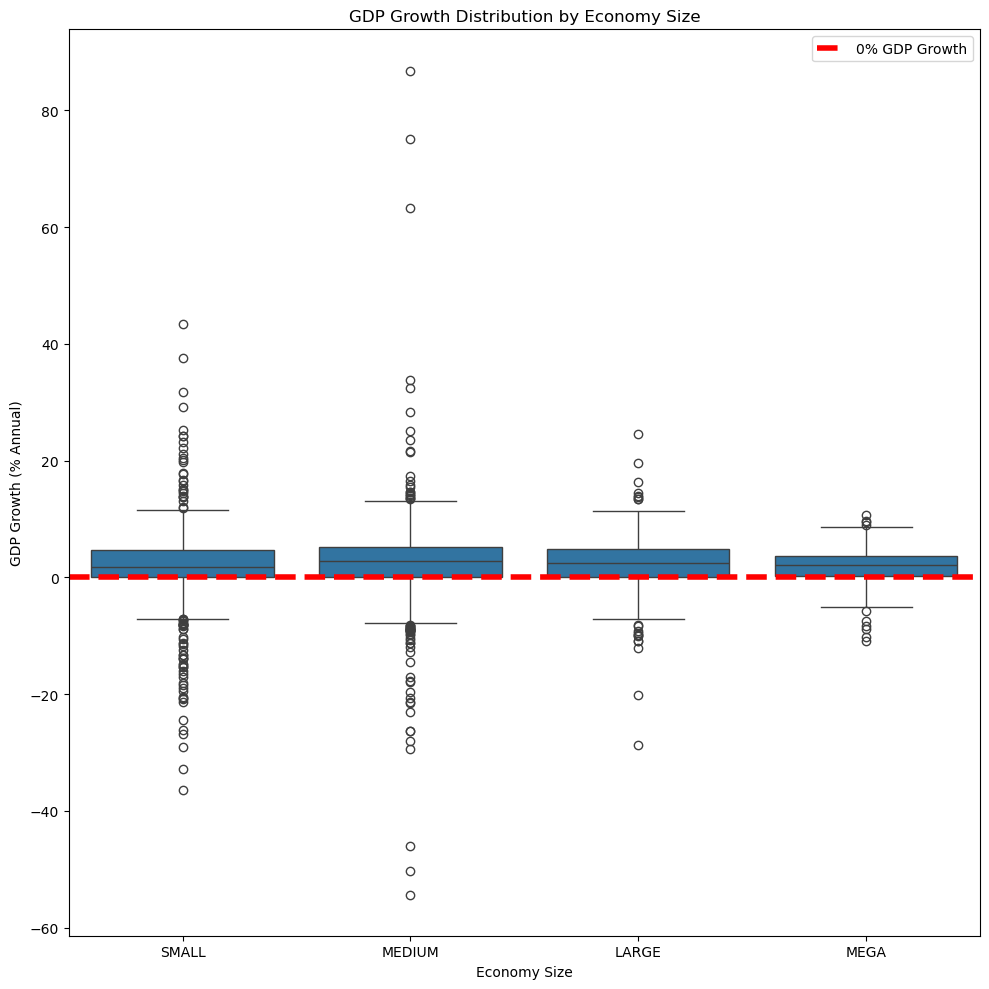

In [44]:
plt.figure(figsize=(10, 10))

# Box plot comparing GDP growth distribution across all 4 economy size categories
# Shows median, spread, outliers for each group — powerful statistical comparison
sns.boxplot(df, x='economy_size', y='GDP Growth (% Annual)')

# Thick red reference line at 0 — clearly separates growth from recession
plt.axhline(y=0, color='red', linestyle='--', linewidth=4, label='0% GDP Growth')
plt.title('GDP Growth Distribution by Economy Size')
plt.xlabel('Economy Size')
plt.ylabel('GDP Growth (% Annual)')
plt.legend()
plt.tight_layout()
plt.show()

## 📊 Analysis 11 — GDP vs GDP per Capita by Economy Size (2025)

**Question:** Can a country have a small total economy but still be very wealthy per person?

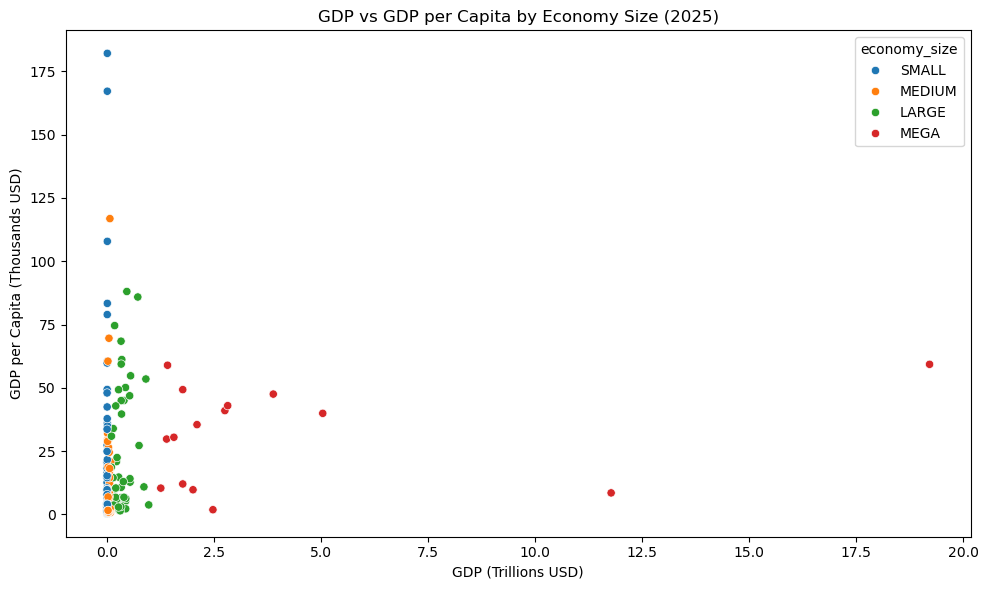

In [45]:
plt.figure(figsize=(10, 6))

# Filtering 2025 for current snapshot
data = df.loc[df['year'] == 2025]

# Scatter plot with hue — each economy size category gets a different color
# Both axes converted — trillions for GDP, thousands for per capita
sns.scatterplot(x=data['GDP (Current USD)'] / 1e12, y=data['GDP per Capita (Current USD)'] / 1e3, hue=data['economy_size'])
plt.title('GDP vs GDP per Capita by Economy Size (2025)')
plt.xlabel('GDP (Trillions USD)')
plt.ylabel('GDP per Capita (Thousands USD)')
plt.tight_layout()
plt.show()

## 📊 Analysis 12 — Inflation Comparison — 6 Major Countries

**Question:** Did all countries experience the same post-COVID inflation spike — or did some suffer more than others?

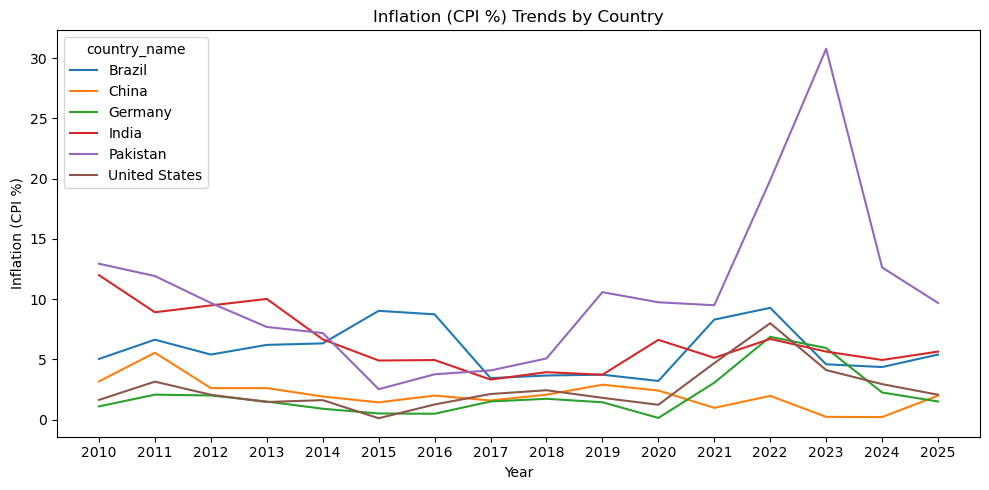

In [46]:
plt.figure(figsize=(10, 5))

# Filtering 6 countries — mix of superpowers, emerging markets and South Asia
# USA, China (superpowers), Germany (Europe), India, Brazil (emerging), Pakistan (South Asia)
data = df.loc[df['country_name'].isin(['United States', 'China', 'Pakistan', 'India', 'Germany', 'Brazil'])]

# Seaborn lineplot with hue — each country gets its own colored line automatically
sns.lineplot(x=data['year'], y=data['Inflation (CPI %)'], hue=data['country_name'])
plt.title('Inflation (CPI %) Trends by Country')
plt.xlabel('Year')
plt.ylabel('Inflation (CPI %)')

# Showing every year on x-axis
plt.xticks(data['year'].unique())
plt.tight_layout()
plt.show()

## 📊 Analysis 13 — GDP Growth Heatmap — 6 Countries (2010–2025)

**Question:** Which country had the worst GDP crash in 2020 — and who recovered fastest?

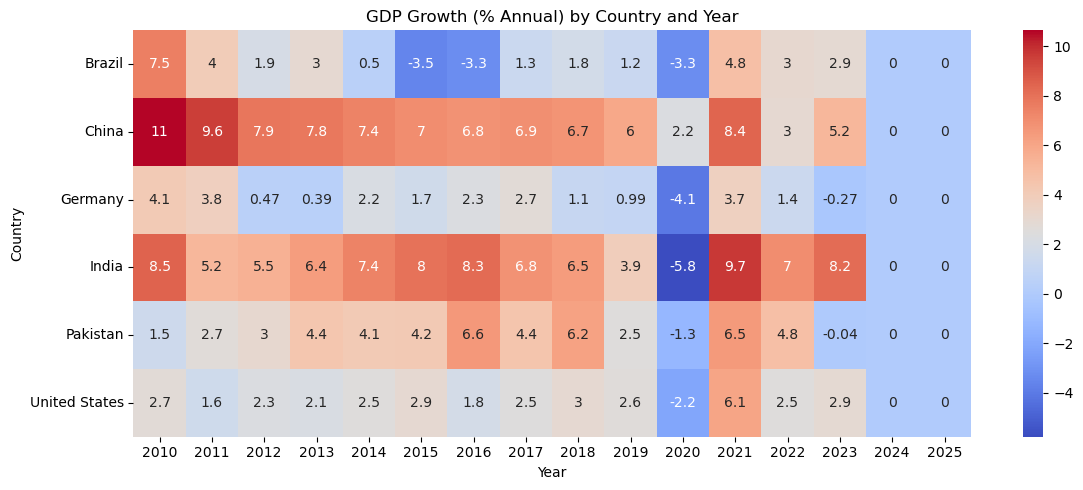

In [47]:
plt.figure(figsize=(12, 5))

# Filtering same 6 countries
data = df.loc[df['country_name'].isin(['United States', 'China', 'Pakistan', 'India', 'Germany', 'Brazil'])]

# pivot() reshapes data — countries as rows, years as columns, GDP growth as values
# This format is required for heatmap visualization
pivot_data = data.pivot(index='country_name', columns='year', values='GDP Growth (% Annual)')

# coolwarm colormap — red = strong growth, blue = recession/shrinking
# annot=True shows exact growth % in every cell
# 2020 COVID crash shows as a clear blue column across all countries
sns.heatmap(pivot_data, cmap='coolwarm', annot=True)
plt.title('GDP Growth (% Annual) by Country and Year')
plt.xlabel('Year')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

## 📊 Analysis 14 — GDP Stack Plot — 6 Major Economies (2010–2025)

**Question:** How has the combined GDP of these 6 economies grown — and which country contributes most?

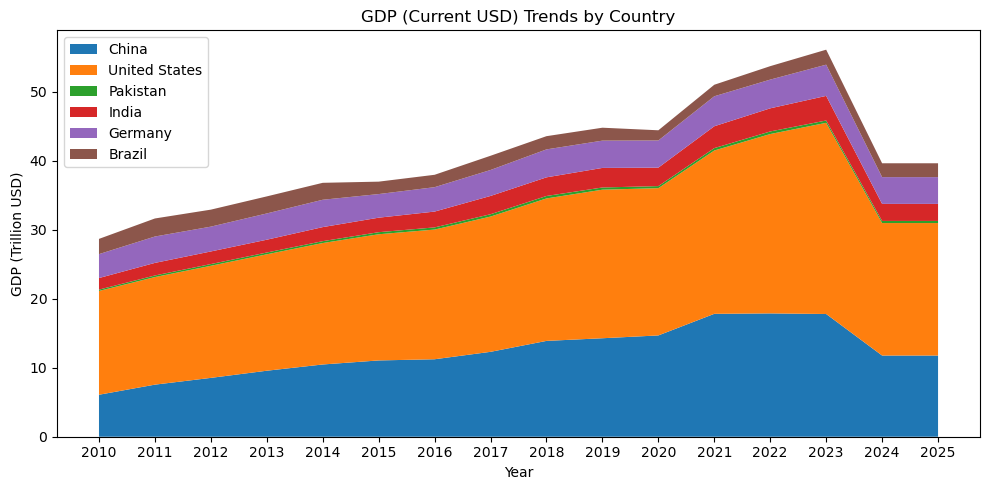

In [48]:
# Filtering same 6 countries
data = df.loc[df['country_name'].isin(['United States', 'China', 'Pakistan', 'India', 'Germany', 'Brazil'])]

# Extracting each country's GDP series separately — required for stackplot
# Each series contains 16 values (one per year 2010-2025), converted to Trillions
china         = data.loc[data['country_name'] == 'China']['GDP (Current USD)']         / 1e12
united_states = data.loc[data['country_name'] == 'United States']['GDP (Current USD)'] / 1e12
pakistan      = data.loc[data['country_name'] == 'Pakistan']['GDP (Current USD)']      / 1e12
india         = data.loc[data['country_name'] == 'India']['GDP (Current USD)']         / 1e12
germany       = data.loc[data['country_name'] == 'Germany']['GDP (Current USD)']       / 1e12
brazil        = data.loc[data['country_name'] == 'Brazil']['GDP (Current USD)']        / 1e12

# Getting unique years as x-axis values
years = data['year'].unique()

plt.figure(figsize=(10, 5))

# Stack plot — each layer shows one country's GDP contribution
# Top of chart shows combined total GDP of all 6 economies growing over time
plt.stackplot(years, china, united_states, pakistan, india, germany, brazil,
              labels=['China', 'United States', 'Pakistan', 'India', 'Germany', 'Brazil'])
plt.title('GDP (Current USD) Trends by Country')
plt.xlabel('Year')
plt.ylabel('GDP (Trillion USD)')
plt.legend()
plt.xticks(years)
plt.tight_layout()
plt.show()

---
## 📊 Final Dashboard — Global Economic Analysis Summary

Combining the 6 most impactful analyses into one complete dashboard.

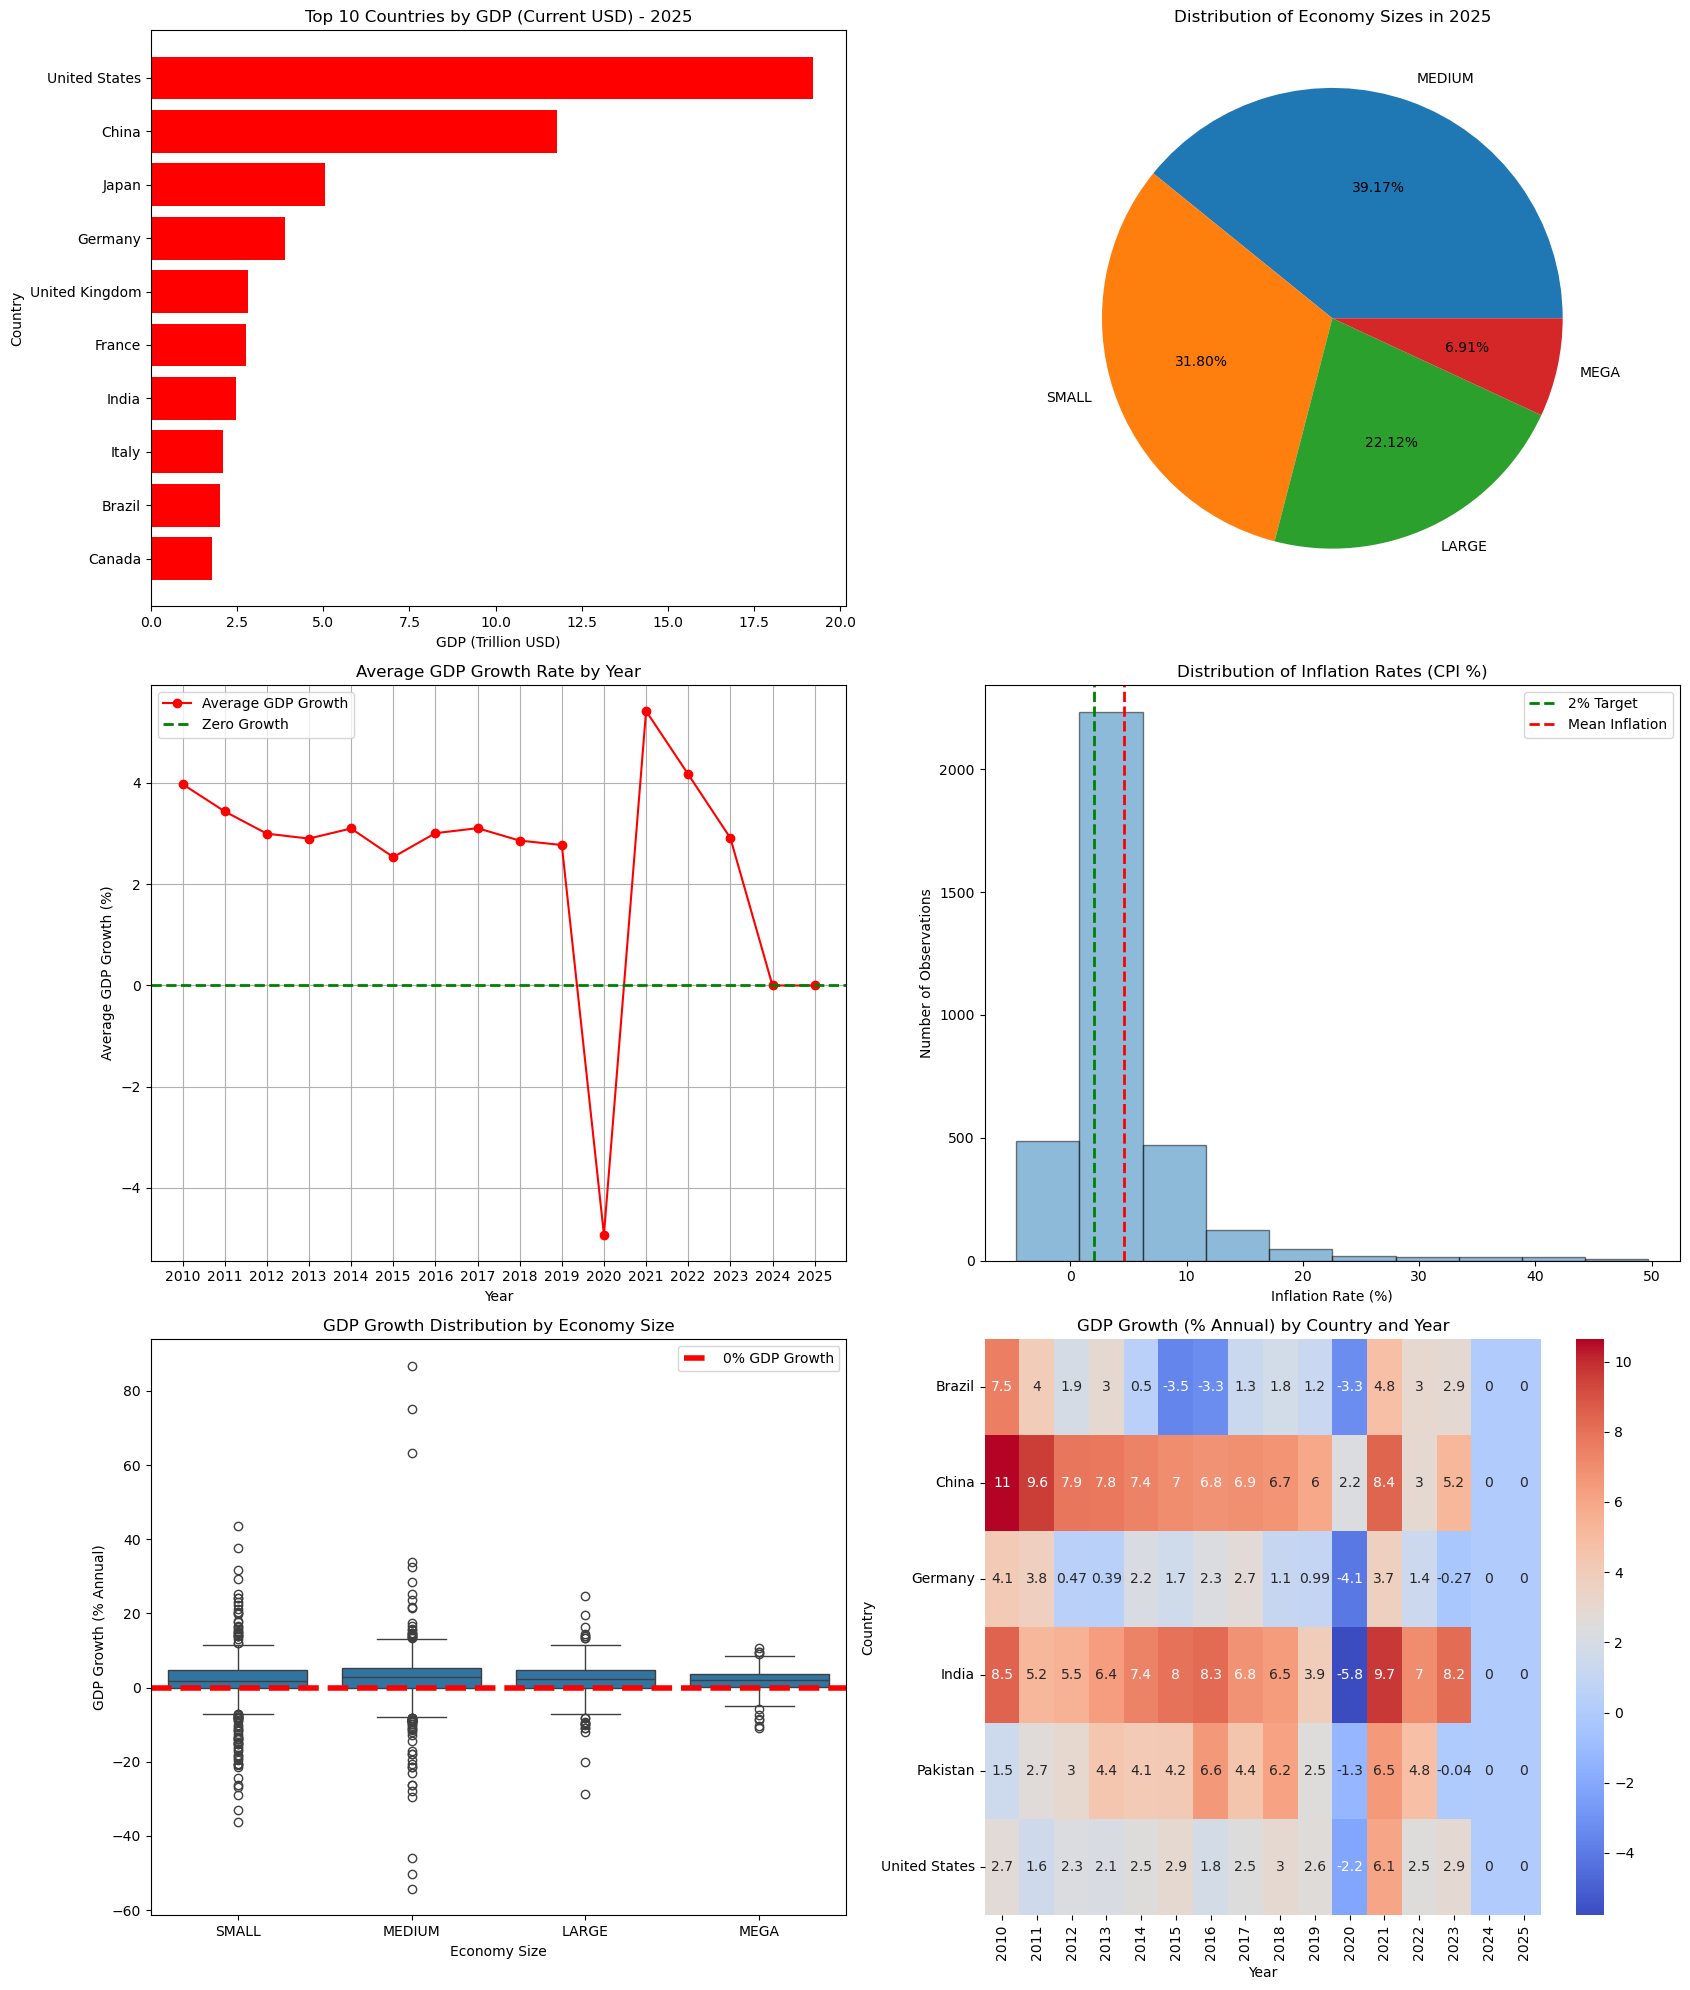

In [49]:
# Creating a 3x2 grid — 6 diverse charts in one professional dashboard
fig, ax = plt.subplots(3, 2, figsize=(17, 20))

# --- SUBPLOT 1 [0][0] --- Top 10 Largest Economies
filtered = df.loc[df['year'] == 2025]
data = filtered.sort_values('GDP (Current USD)').tail(10)
ax[0][0].barh(data['country_name'], data['GDP (Current USD)'] / 1e12, color='red')
ax[0][0].set_title('Top 10 Countries by GDP (Current USD) - 2025')
ax[0][0].set_xlabel('GDP (Trillion USD)')
ax[0][0].set_ylabel('Country')

# --- SUBPLOT 2 [0][1] --- Economy Size Distribution Pie Chart
data = filtered['economy_size'].value_counts()
ax[0][1].pie(data.values, labels=data.index, autopct='%1.2f%%')
ax[0][1].set_title('Distribution of Economy Sizes in 2025')

# --- SUBPLOT 3 [1][0] --- Global GDP Growth Rate with COVID Crash
# The most dramatic chart — 2020 COVID dip clearly visible below zero line
data = df.groupby('year')['GDP Growth (% Annual)'].mean()
ax[1][0].plot(data.index, data.values, marker='o', label='Average GDP Growth', color='red')
ax[1][0].axhline(y=0, color='green', linestyle='--', linewidth=2, label='Zero Growth')
ax[1][0].set_title('Average GDP Growth Rate by Year')
ax[1][0].set_xlabel('Year')
ax[1][0].set_ylabel('Average GDP Growth (%)')
ax[1][0].legend()
ax[1][0].grid()
ax[1][0].set_xticks(data.index)

# --- SUBPLOT 4 [1][1] --- Inflation Distribution Histogram
# Filtered to -5% to 50% range to remove hyperinflation outliers
data = df.loc[((df['Inflation (CPI %)'] >= -5) & (df['Inflation (CPI %)'] <= 50))]
ax[1][1].hist(data['Inflation (CPI %)'], edgecolor='black', alpha=0.5)
ax[1][1].axvline(x=2, color='green', linestyle='--', linewidth=2, label='2% Target')
ax[1][1].axvline(x=data['Inflation (CPI %)'].mean(), color='red', linestyle='--', linewidth=2, label='Mean Inflation')
ax[1][1].set_title('Distribution of Inflation Rates (CPI %)')
ax[1][1].set_xlabel('Inflation Rate (%)')
ax[1][1].set_ylabel('Number of Observations')
ax[1][1].legend()

# --- SUBPLOT 5 [2][0] --- GDP Growth by Economy Size Box Plot
# ax= directs Seaborn to draw on this specific subplot
sns.boxplot(df, x='economy_size', y='GDP Growth (% Annual)', ax=ax[2][0])
ax[2][0].axhline(y=0, color='red', linestyle='--', linewidth=4, label='0% GDP Growth')
ax[2][0].set_title('GDP Growth Distribution by Economy Size')
ax[2][0].set_xlabel('Economy Size')
ax[2][0].set_ylabel('GDP Growth (% Annual)')
ax[2][0].legend()

# --- SUBPLOT 6 [2][1] --- GDP Growth Heatmap — Most Powerful Chart
# pivot() reshapes data — coolwarm shows growth vs recession clearly
data = df.loc[df['country_name'].isin(['United States', 'China', 'Pakistan', 'India', 'Germany', 'Brazil'])]
pivot_data = data.pivot(index='country_name', columns='year', values='GDP Growth (% Annual)')
sns.heatmap(pivot_data, cmap='coolwarm', annot=True, ax=ax[2][1])
ax[2][1].set_title('GDP Growth (% Annual) by Country and Year')
ax[2][1].set_xlabel('Year')
ax[2][1].set_ylabel('Country')

fig.tight_layout()
plt.show()

---
## 🔍 Dataset Preview

In [50]:
# Displaying first 5 rows of the cleaned dataset
df.head()

,country_name,year,Inflation (CPI %),GDP (Current USD),GDP per Capita (Current USD),Unemployment Rate (%),"Inflation (GDP Deflator, %)",GDP Growth (% Annual),Current Account Balance (% GDP),Gross National Income (USD),economy_size
0,Aruba,2010,2.078141,2.453597e+09,24093.140151,5.794,-1.223407,-2.733457,-18.752537,2.313385e+09,SMALL
1,Aruba,2011,4.316297,2.637859e+09,25712.384302,5.794,4.005674,3.369237,-9.877656,2.391841e+09,SMALL
2,Aruba,2012,0.627472,2.615208e+09,25119.665545,5.794,0.184033,-1.040800,3.473451,2.499118e+09,SMALL
3,Aruba,2013,-2.372065,2.727850e+09,25813.576727,5.794,-1.995948,6.431483,-11.813206,2.563517e+09,SMALL
4,Aruba,2014,0.421441,2.790850e+09,26129.839062,5.794,3.958897,-1.586575,-4.658577,2.688102e+09,SMALL
